## Kuvantunnistusjärjestelmä

Tässä projektissa toteutetaan kuvantunnistusjärjestelmä, joka oppii tunnistamaan kolme eri luokkaa: mukit (mugs), pullot (bottles) ja kirjat (books). Projektin tavoitteena on ymmärtää, miten erilaiset syväoppimisen mallit toimivat kuvantunnistuksessa ja miten niiden suorituskyky vaihtelee.

Projektissa käytetään itse kerättyä kuvadataa, jossa on 50 kuvaa jokaisesta luokasta. Kuvat on jaettu harjoitus-, validointi- ja testiaineistoihin, jotta mallien oppimista ja yleistämiskykyä voidaan arvioida mahdollisimman realistisesti.

Työssä toteutetaan kolme erilaista mallia:

Yksinkertainen konvoluutioneuroverkko (CNN), joka opetetaan alusta alkaen
Esikoulutettu VGG16-malli piirteiden erotteluun
Hienosäädetty VGG16-malli, jossa osia verkosta opetetaan uudelleen

Projektin tarkoituksena on vertailla näiden lähestymistapojen eroja sekä tarkkuutta että yleistämiskykyä käyttäen samaa datasettiä. Lisäksi analysoidaan mallien vahvuuksia ja heikkouksia pienellä kuvadatalla.

### Importit

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

### Datan lataus

Kuvat ladataan kansiorakenteesta. Jokainen kansio vastaa yhtä luokkaa (mugs, bottles, flowers). Kuvat muutetaan automaattisesti samaan kokoon (224x224).

In [4]:
img_size = (224, 224)
batch_size = 16

train_ds = keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=img_size,
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    "dataset/val",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=img_size,
    batch_size=batch_size
)

Found 105 files belonging to 3 classes.
Found 21 files belonging to 3 classes.
Found 24 files belonging to 3 classes.


### Esikäsittely + augmentaatio

Kuvia muokataan hieman, jotta malli oppii paremmin erilaisia tilanteita. Tämä parantaa yleistämistä.

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

normalization = layers.Rescaling(1./255)

### MALLI 1: Oma CNN 

Tämä on yksinkertainen konvoluutioneuroverkko, joka opetetaan täysin alusta. Se toimii vertailupohjana muille malleille.

In [6]:
model1 = keras.Sequential([
    normalization,
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

Mallia opetetaan training-datalla ja seurataan validointia.

In [7]:
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 823ms/step - accuracy: 0.2762 - loss: 2.6024 - val_accuracy: 0.3333 - val_loss: 1.1404
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3905 - loss: 1.0939 - val_accuracy: 0.3333 - val_loss: 1.1303
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3333 - loss: 1.1268 - val_accuracy: 0.5714 - val_loss: 1.0670
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 707ms/step - accuracy: 0.4095 - loss: 1.0849 - val_accuracy: 0.3333 - val_loss: 1.0185
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 777ms/step - accuracy: 0.4286 - loss: 0.9960 - val_accuracy: 0.5238 - val_loss: 0.8896
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 722ms/step - accuracy: 0.6381 - loss: 0.8114 - val_accuracy: 0.7143 - val_loss: 0.8721
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 740ms/step - accuracy: 0.6857 - loss: 0.6973 - val_accuracy: 0.6190 - val_loss: 0.8233
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 780ms/step - accuracy: 0.8095 - loss: 0.5054 - val_accuracy: 0.6190 - val_loss: 1.2

### MALLI 2: VGG16 feature extraction

Käytetään valmiiksi opetettua VGG16-mallia. Se tunnistaa kuvista yleisiä piirteitä (reunat, muodot), mutta ei itse opi luokkia.

In [8]:
base_model = keras.applications.VGG16(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)

base_model.trainable = False

Lisätään oma "päätöskerros", joka oppii luokat.

In [9]:
model2 = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.4286 - loss: 3.1781 - val_accuracy: 0.5238 - val_loss: 1.7494
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.7333 - loss: 0.9163 - val_accuracy: 0.6190 - val_loss: 1.3512
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8476 - loss: 0.2670 - val_accuracy: 0.7619 - val_loss: 1.0148
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9619 - loss: 0.1256 - val_accuracy: 0.7143 - val_loss: 0.9612
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.9810 - loss: 0.0812 - val_accuracy: 0.6667 - val_loss: 1.2133
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.9905 - loss: 0.0439 - val_accuracy: 0.6667 - val_loss: 1.0205
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9905 - loss: 0.0321 - val_accuracy: 0.6667 - val_loss: 1.0643
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 1.0000 - loss: 0.0254 - val_accuracy: 0.7143 - val_loss: 0.9393
Epoch 9/

### MALLI 3: Fine-tuning VGG16

Tässä mallissa VGG16:n viimeisiä kerroksia opetetaan uudelleen omalla datalla. Tämä yleensä parantaa tarkkuutta.

In [10]:
base_model.trainable = True

# jäädytetään alemmat kerrokset
for layer in base_model.layers[:15]:
    layer.trainable = False

In [11]:
model3 = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model3.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.3429 - loss: 3.4447 - val_accuracy: 0.5714 - val_loss: 1.1395
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.4952 - loss: 1.3851 - val_accuracy: 0.5238 - val_loss: 0.8848
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.7619 - loss: 0.5828 - val_accuracy: 0.5714 - val_loss: 1.1464
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8857 - loss: 0.3466 - val_accuracy: 0.5714 - val_loss: 1.1468
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.9429 - loss: 0.1881 - val_accuracy: 0.5714 - val_loss: 0.9704


### Mallien vertailu

Testidatalla tarkistetaan, mikä malli toimii parhaiten oikeassa käytössä.

In [12]:
print("CNN:", model1.evaluate(test_ds))
print("VGG16 feature:", model2.evaluate(test_ds))
print("Fine-tuned:", model3.evaluate(test_ds))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7083 - loss: 1.7311
CNN: [1.7310789823532104, 0.7083333134651184]
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8333 - loss: 0.3427
VGG16 feature: [0.3427104651927948, 0.8333333134651184]
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4583 - loss: 1.3848
Fine-tuned: [1.3848484754562378, 0.4583333432674408]


### Oppimiskäyrät

Kuvataan, miten tarkkuus kehittyy harjoituksen aikana.

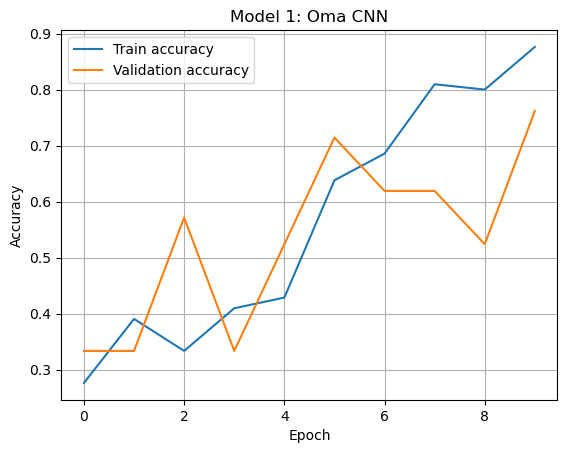

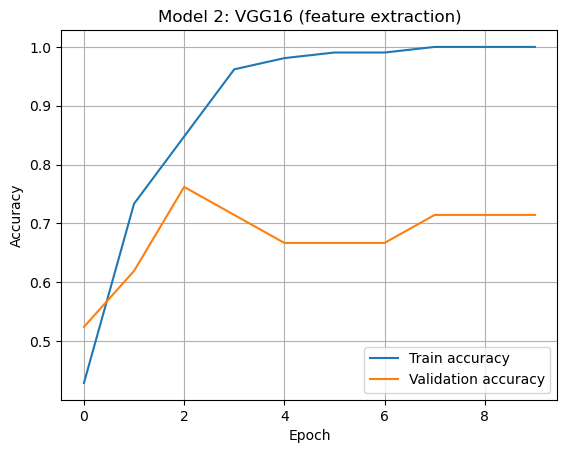

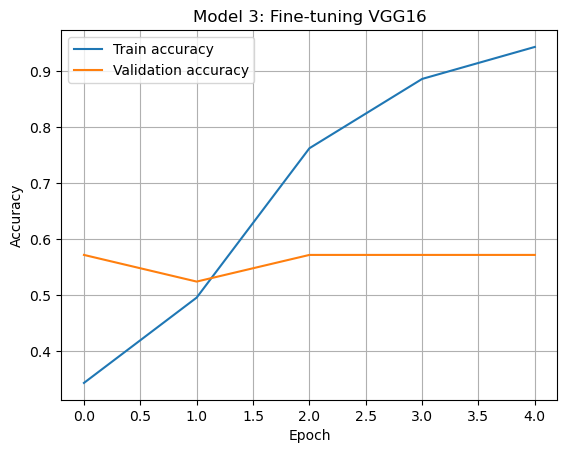

In [17]:
def plot_history(history, title):
    plt.figure()
    
    plt.plot(history.history['accuracy'], label='Train accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation accuracy')
    
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    
    plt.legend()
    plt.grid()
    plt.show()
    
plot_history(history1, "Model 1: Oma CNN")
plot_history(history2, "Model 2: VGG16 (feature extraction)")
plot_history(history3, "Model 3: Fine-tuning VGG16")

### Väärin luokitellut kuvat

Tarkastellaan esimerkkejä, joissa malli teki virheen. Tämä auttaa ymmärtämään mallin heikkouksia.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


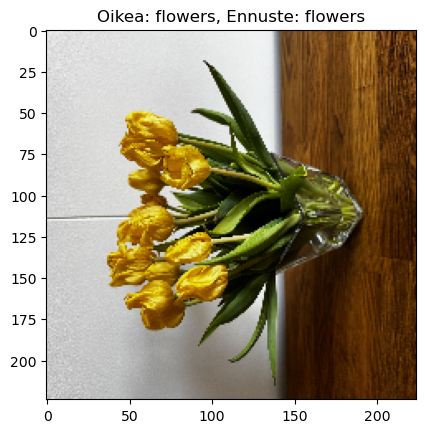

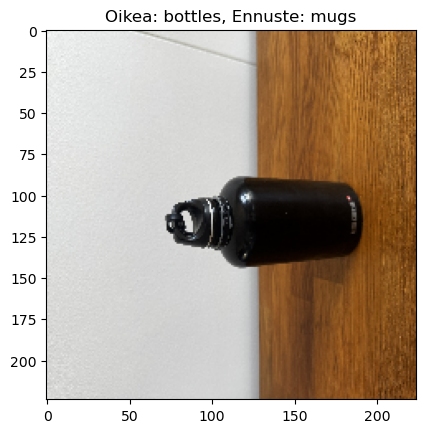

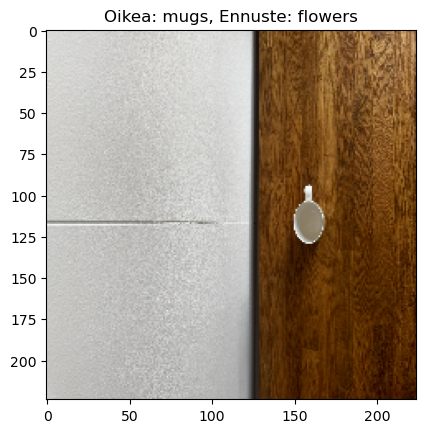

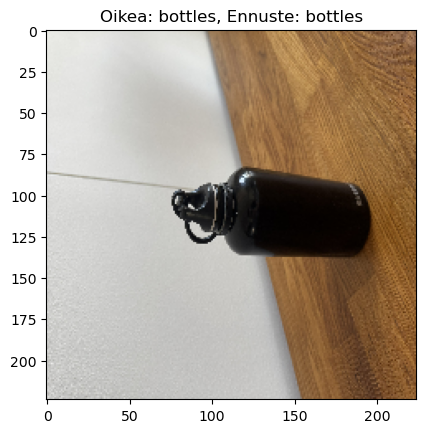

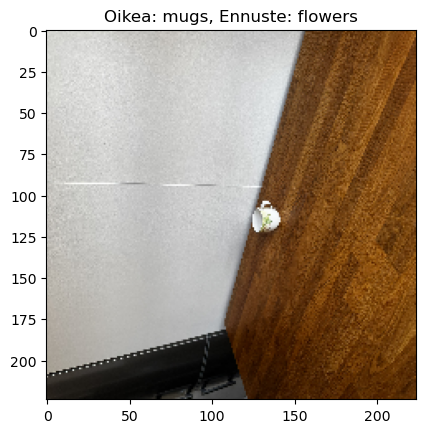

In [15]:
import numpy as np

images, labels = next(iter(test_ds))
preds = model3.predict(images)
pred_labels = np.argmax(preds, axis=1)

class_names = train_ds.class_names

for i in range(5):
    plt.imshow(images[i].numpy().astype("uint8"))
    
    true_label = class_names[labels[i]]
    pred_label = class_names[pred_labels[i]]
    
    plt.title(f"Oikea: {true_label}, Ennuste: {pred_label}")
    plt.show()